# Классификация IC50 > медиана


In [1]:
# Установка библиотек для Google Colab
!pip -q install xgboost lightgbm openpyxl seaborn


In [2]:
# Загрузка исходного файла с данными

import os
from google.colab import files

DATA_PATH = '/content/drug_data.xlsx'

if not os.path.exists(DATA_PATH):
    uploaded = files.upload()
    if 'drug_data.xlsx' not in uploaded:

        first_file = next(iter(uploaded.keys()))
        os.rename(first_file, DATA_PATH)

os.makedirs('reports', exist_ok=True)
os.makedirs('models', exist_ok=True)
print(f'Файл данных: {DATA_PATH}')
print('Папки reports/ и models/ готовы')


Файл данных: /content/drug_data.xlsx
Папки reports/ и models/ готовы


## Основной код

КЛАССИФИКАЦИЯ: IC50 > МЕДИАНА
Медиана IC50: 46.585
Распределение классов:
  IC50 <= медиана (0): 501 (50.0%)
  IC50 > медиана (1):  500 (50.0%)
Количество признаков: 210
Удаляем 18 константных признаков
Обработаны пропущенные значения (NaNs).
Удаляем 32 высококоррелированных признаков
Итоговое количество признаков: 160
Обучающая выборка: (800, 160)
Тестовая выборка: (201, 160)

Распределение в обучающей выборке:
  Класс 0: 400 (50.0%)
  Класс 1: 400 (50.0%)

1. ОПРЕДЕЛЕНИЕ МОДЕЛЕЙ
----------------------------------------
Определено 9 моделей:
   1. Logistic Regression
   2. Random Forest
   3. Extra Trees
   4. Gradient Boosting
   5. XGBoost
   6. LightGBM
   7. SVM
   8. Neural Network
   9. Naive Bayes

2. КРОСС-ВАЛИДАЦИЯ МОДЕЛЕЙ
----------------------------------------
Обучение Logistic Regression...
  Accuracy: 0.680 ± 0.022
  F1-Score: 0.683 ± 0.023
  ROC AUC:  0.741 ± 0.023
Обучение Random Forest...
  Accuracy: 0.741 ± 0.023
  F1-Score: 0.737 ± 0.022
  ROC AUC:  0.814 ± 0.020
Об

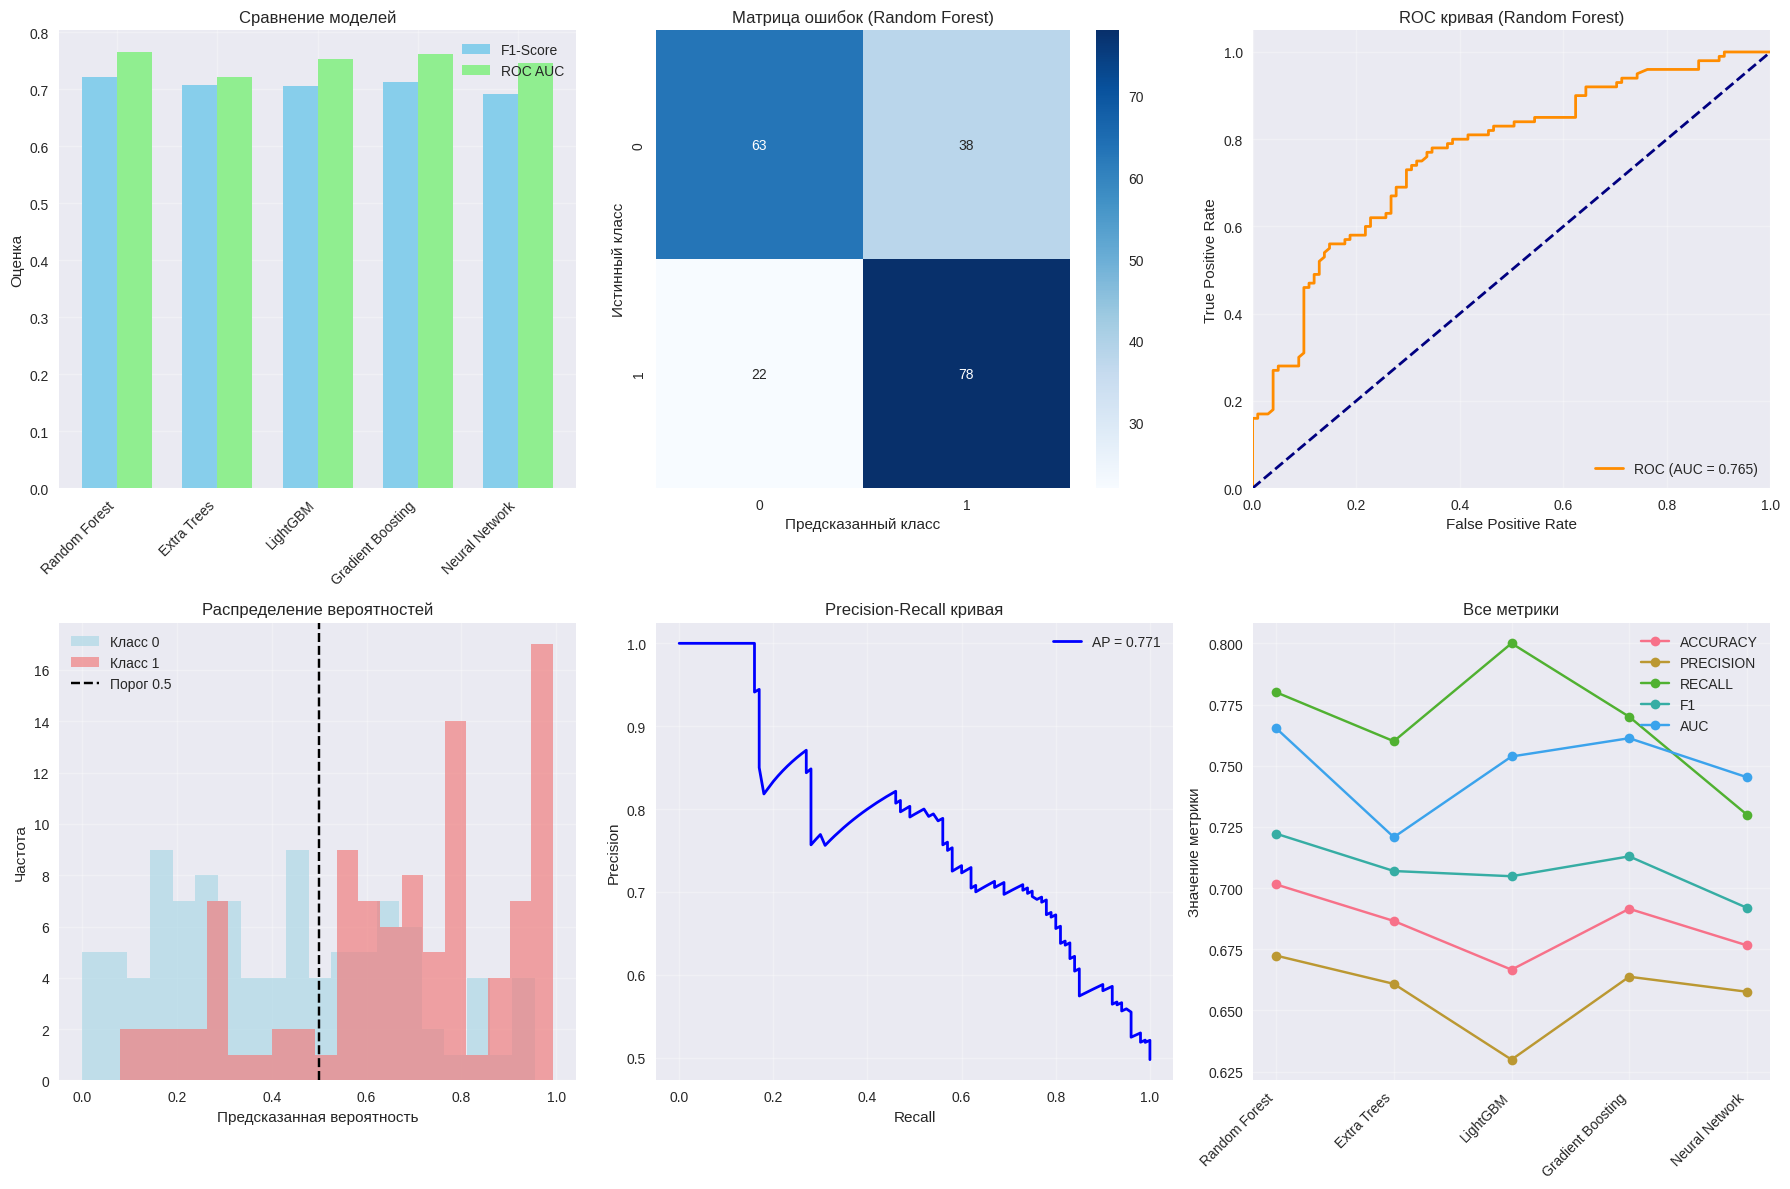


6. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
----------------------------------------
Топ-20 наиболее важных признаков:
  19. BCUT2D_MRLOW                   | 0.0345
  82. VSA_EState8                    | 0.0274
  13. BCUT2D_MWLOW                   | 0.0170
   8. MaxAbsPartialCharge            | 0.0166
  78. VSA_EState4                    | 0.0165
  99. MolLogP                        | 0.0159
   7. MinPartialCharge               | 0.0157
  72. EState_VSA8                    | 0.0156
  58. SlogP_VSA5                     | 0.0152
  42. PEOE_VSA9                      | 0.0151
  68. EState_VSA4                    | 0.0150
  11. FpDensityMorgan3               | 0.0147
  15. BCUT2D_CHGLO                   | 0.0146
  40. PEOE_VSA7                      | 0.0141
   3. MinEStateIndex                 | 0.0141
  25. HallKierAlpha                  | 0.0141
  81. VSA_EState7                    | 0.0140
  16. BCUT2D_LOGPHI                  | 0.0140
   2. MinAbsEStateIndex              | 0.0138
  17. BCUT2D_LOGPLOW 

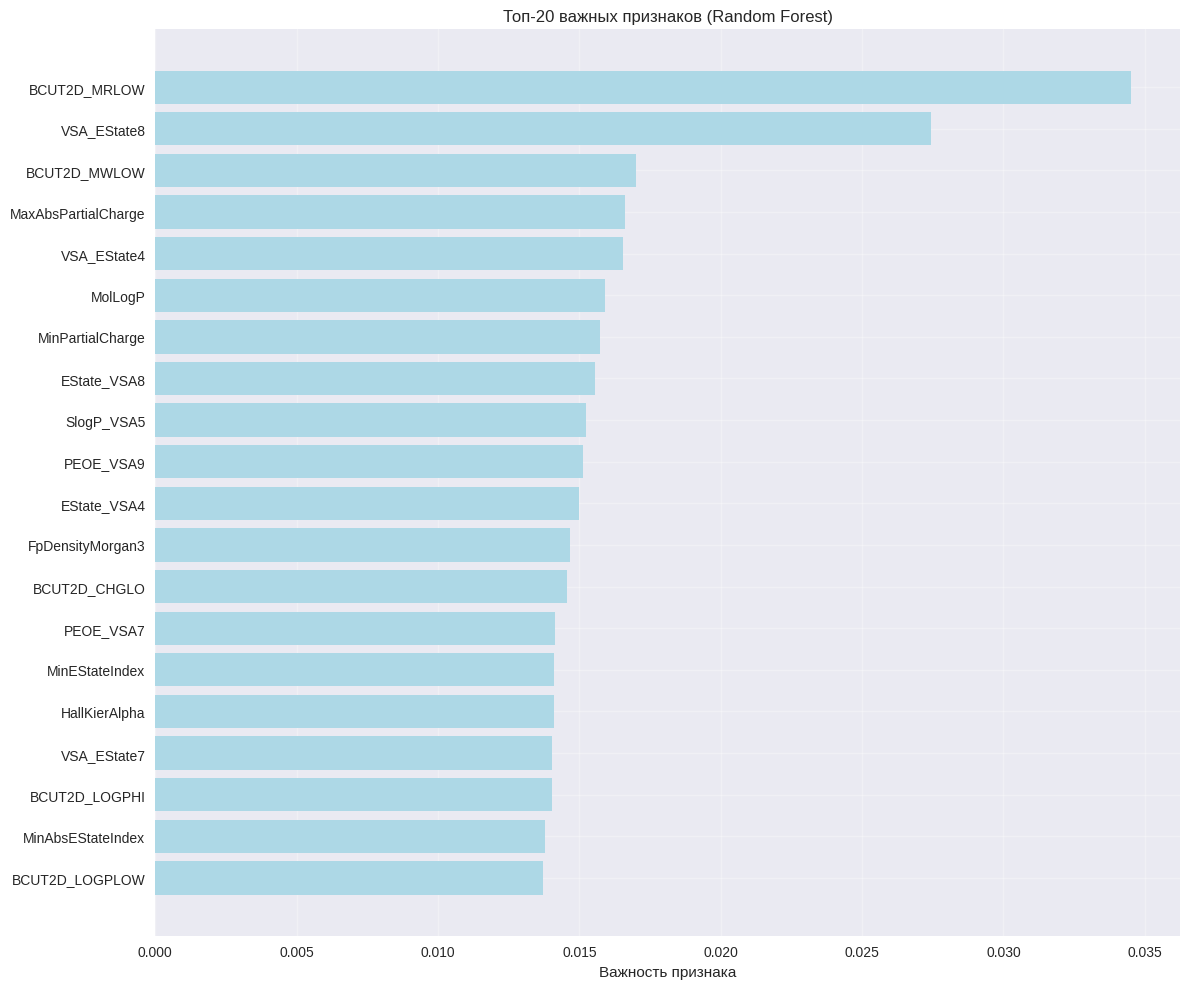


7. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
----------------------------------------
Результаты сохранены:
  • reports/ic50_classification_results.csv
  • reports/ic50_classification_feature_importance.csv
  • reports/ic50_classification_predictions.csv

КЛАССИФИКАЦИЯ IC50 ЗАВЕРШЕНА!
Лучшая модель: Random Forest
F1-Score: 0.722
ROC AUC: 0.765
Порог IC50: 46.585


In [4]:

"""
Модели классификации для IC50 > медиана
Предсказание превышения медианного значения IC50

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                           accuracy_score, precision_score, recall_score, f1_score, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer # Import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette("husl")

class IC50ClassificationPredictor:
    """Класс для классификации IC50 > медиана"""

    def __init__(self):
        self.models = {}
        self.results = {}
        self.best_model = None
        self.threshold = None

    def load_and_prepare_data(self):
        """Загрузка и подготовка данных"""
        print("="*60)
        print("КЛАССИФИКАЦИЯ: IC50 > МЕДИАНА")
        print("="*60)

        # Загрузка данных
        df = pd.read_excel(DATA_PATH)

        # Переименование целевых столбцов
        df = df.rename(columns={'IC50, mM': 'IC50', 'CC50, mM': 'CC50'})

        # Удаление индексного столбца
        if 'Unnamed: 0' in df.columns:
            df = df.drop('Unnamed: 0', axis=1)

        # Вычисление медианы IC50
        self.threshold = df['IC50'].median()
        print(f"Медиана IC50: {self.threshold:.3f}")

        # Создание бинарной целевой переменной
        y = (df['IC50'] > self.threshold).astype(int)

        print(f"Распределение классов:")
        print(f"  IC50 <= медиана (0): {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")
        print(f"  IC50 > медиана (1):  {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")

        # Признаки (исключаем все целевые переменные)
        feature_cols = [col for col in df.columns if col not in ['IC50', 'CC50', 'SI']]
        X = df[feature_cols].copy()

        print(f"Количество признаков: {X.shape[1]}")

        # Удаление константных признаков
        constant_features = X.columns[X.nunique() <= 1]
        if len(constant_features) > 0:
            print(f"Удаляем {len(constant_features)} константных признаков")
            X = X.drop(constant_features, axis=1)

        # Impute missing values before correlation calculation and splitting
        imputer = SimpleImputer(strategy='mean')
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
        print(f"Обработаны пропущенные значения (NaNs).")

        # Удаление высококоррелированных признаков
        corr_matrix = X.corr().abs()
        upper_triangle = np.triu(np.ones_like(corr_matrix), k=1)
        high_corr_pairs = np.where((corr_matrix > 0.95) & upper_triangle)

        features_to_remove = set()
        for i in range(len(high_corr_pairs[0])):
            idx1, idx2 = high_corr_pairs[0][i], high_corr_pairs[1][i]
            feature1, feature2 = X.columns[idx1], X.columns[idx2]
            # Удаляем признак с меньшей корреляцией с целевой переменной
            corr1 = abs(np.corrcoef(X[feature1], y)[0,1])
            corr2 = abs(np.corrcoef(X[feature2], y)[0,1])
            if corr1 < corr2:
                features_to_remove.add(feature1)
            else:
                features_to_remove.add(feature2)

        if features_to_remove:
            print(f"Удаляем {len(features_to_remove)} высококоррелированных признаков")
            X = X.drop(list(features_to_remove), axis=1)

        print(f"Итоговое количество признаков: {X.shape[1]}")

        # Разделение на обучающую и тестовую выборки
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        print(f"Обучающая выборка: {self.X_train.shape}")
        print(f"Тестовая выборка: {self.X_test.shape}")

        # Проверяем стратификацию
        print(f"\nРаспределение в обучающей выборке:")
        print(f"  Класс 0: {(self.y_train == 0).sum()} ({(self.y_train == 0).mean()*100:.1f}%)")
        print(f"  Класс 1: {(self.y_train == 1).sum()} ({(self.y_train == 1).mean()*100:.1f}%)")

        return X, y

    def define_models(self):
        """Определение моделей для тестирования"""
        print(f"\n1. ОПРЕДЕЛЕНИЕ МОДЕЛЕЙ")
        print("-"*40)

        self.models = {
            'Logistic Regression': Pipeline([
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(random_state=42, max_iter=1000))
            ]),

            'Random Forest': RandomForestClassifier(
                n_estimators=100, random_state=42, n_jobs=-1
            ),

            'Extra Trees': ExtraTreesClassifier(
                n_estimators=100, random_state=42, n_jobs=-1
            ),

            'Gradient Boosting': GradientBoostingClassifier(
                random_state=42
            ),

            'XGBoost': xgb.XGBClassifier(
                random_state=42, n_jobs=-1, verbosity=0, eval_metric='logloss'
            ),

            'LightGBM': lgb.LGBMClassifier(
                random_state=42, n_jobs=-1, verbosity=-1
            ),

            'SVM': Pipeline([
                ('scaler', StandardScaler()),
                ('model', SVC(random_state=42, probability=True))
            ]),

            'Neural Network': Pipeline([
                ('scaler', StandardScaler()),
                ('model', MLPClassifier(random_state=42, max_iter=500))
            ]),

            'Naive Bayes': Pipeline([
                ('scaler', StandardScaler()),
                ('model', GaussianNB())
            ])
        }

        print(f"Определено {len(self.models)} моделей:")
        for i, name in enumerate(self.models.keys(), 1):
            print(f"  {i:2d}. {name}")

    def evaluate_models(self):
        """Оценка всех моделей с кросс-валидацией"""
        print(f"\n2. КРОСС-ВАЛИДАЦИЯ МОДЕЛЕЙ")
        print("-"*40)

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

        for name, model in self.models.items():
            print(f"Обучение {name}...")

            model_results = {}

            for metric in metrics:
                scores = cross_val_score(
                    model, self.X_train, self.y_train,
                    cv=cv, scoring=metric, n_jobs=-1
                )

                model_results[f'{metric}_mean'] = scores.mean()
                model_results[f'{metric}_std'] = scores.std()
                model_results[f'{metric}_scores'] = scores

            self.results[name] = model_results

            print(f"  Accuracy: {model_results['accuracy_mean']:.3f} \u00b1 {model_results['accuracy_std']:.3f}")
            print(f"  F1-Score: {model_results['f1_mean']:.3f} \u00b1 {model_results['f1_std']:.3f}")
            print(f"  ROC AUC:  {model_results['roc_auc_mean']:.3f} \u00b1 {model_results['roc_auc_std']:.3f}")

        # Сортировка по F1-score
        sorted_models = sorted(
            self.results.items(),
            key=lambda x: x[1]['f1_mean'],
            reverse=True
        )

        print(f"\nРАНГИ МОДЕЛЕЙ (по F1-score):")
        print("-"*50)
        for i, (name, metrics) in enumerate(sorted_models, 1):
            print(f"{i:2d}. {name:<20} | F1: {metrics['f1_mean']:.3f} | AUC: {metrics['roc_auc_mean']:.3f}")

        return sorted_models

    def hyperparameter_tuning(self, top_models=3):
        """Настройка гиперпараметров для лучших моделей"""
        print(f"\n3. НАСТРОЙКА ГИПЕРПАРАМЕТРОВ")
        print("-"*40)

        # Получаем топ модели
        sorted_models = sorted(
            self.results.items(),
            key=lambda x: x[1]['f1_mean'],
            reverse=True
        )

        param_grids = {
            'Random Forest': {
                'n_estimators': [50, 100, 200],
                'max_depth': [10, 20, None],
                'min_samples_split': [2, 5, 10],
                'class_weight': [None, 'balanced']
            },

            'XGBoost': {
                'n_estimators': [50, 100, 200],
                'max_depth': [3, 6, 10],
                'learning_rate': [0.01, 0.1, 0.2],
                'scale_pos_weight': [1, 2, 3]
            },

            'LightGBM': {
                'n_estimators': [50, 100, 200],
                'max_depth': [3, 6, 10],
                'learning_rate': [0.01, 0.1, 0.2],
                'class_weight': [None, 'balanced']
            },

            'Logistic Regression': {
                'model__C': [0.1, 1.0, 10.0],
                'model__class_weight': [None, 'balanced']
            },

            'SVM': {
                'model__C': [0.1, 1, 10],
                'model__gamma': ['scale', 'auto'],
                'model__class_weight': [None, 'balanced']
            }
        }

        tuned_models = {}

        for name, _ in sorted_models[:top_models]:
            if name in param_grids:
                print(f"Настройка {name}...")

                grid_search = GridSearchCV(
                    self.models[name],
                    param_grids[name],
                    cv=3,
                    scoring='f1',
                    n_jobs=-1,
                    verbose=0
                )

                grid_search.fit(self.X_train, self.y_train)

                tuned_models[name] = {
                    'model': grid_search.best_estimator_,
                    'best_params': grid_search.best_params_,
                    'best_score': grid_search.best_score_
                }

                print(f"  Лучший F1: {grid_search.best_score_:.3f}")
                print(f"  Лучшие параметры: {grid_search.best_params_}")
            else:
                # Используем базовую модель
                model = self.models[name]
                model.fit(self.X_train, self.y_train)

                tuned_models[name] = {
                    'model': model,
                    'best_params': {},
                    'best_score': 0
                }

        return tuned_models

    def final_evaluation(self, tuned_models):
        """Финальная оценка на тестовой выборке"""
        print(f"\n4. ФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ")
        print("-"*40)

        final_results = {}

        for name, model_info in tuned_models.items():
            model = model_info['model']

            # Предсказания
            y_pred = model.predict(self.X_test)
            y_pred_proba = model.predict_proba(self.X_test)[:, 1]

            # Метрики
            accuracy = accuracy_score(self.y_test, y_pred)
            precision = precision_score(self.y_test, y_pred)
            recall = recall_score(self.y_test, y_pred)
            f1 = f1_score(self.y_test, y_pred)
            auc = roc_auc_score(self.y_test, y_pred_proba)

            final_results[name] = {
                'model': model,
                'y_pred': y_pred,
                'y_pred_proba': y_pred_proba,
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'auc': auc
            }

            print(f"{name}:")
            print(f"  Accuracy:  {accuracy:.3f}")
            print(f"  Precision: {precision:.3f}")
            print(f"  Recall:    {recall:.3f}")
            print(f"  F1-Score:  {f1:.3f}")
            print(f"  ROC AUC:   {auc:.3f}")
            print()

        # Определяем лучшую модель по F1-score
        best_model_name = max(final_results.keys(),
                             key=lambda x: final_results[x]['f1'])
        self.best_model = final_results[best_model_name]['model']

        print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
        print(f"F1-Score: {final_results[best_model_name]['f1']:.3f}")
        print(f"ROC AUC: {final_results[best_model_name]['auc']:.3f}")

        return final_results, best_model_name

    def create_visualizations(self, final_results, best_model_name):
        """Создание визуализаций результатов"""
        print(f"\n5. СОЗДАНИЕ ВИЗУАЛИЗАЦИЙ")
        print("-"*40)

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # 1. Сравнение метрик
        model_names = list(final_results.keys())
        f1_scores = [final_results[name]['f1'] for name in model_names]
        auc_scores = [final_results[name]['auc'] for name in model_names]

        x_pos = np.arange(len(model_names))
        width = 0.35

        axes[0, 0].bar(x_pos - width/2, f1_scores, width, label='F1-Score', color='skyblue')
        axes[0, 0].bar(x_pos + width/2, auc_scores, width, label='ROC AUC', color='lightgreen')
        axes[0, 0].set_xticks(x_pos)
        axes[0, 0].set_xticklabels(model_names, rotation=45, ha='right')
        axes[0, 0].set_ylabel('Оценка')
        axes[0, 0].set_title('Сравнение моделей')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # 2. Матрица ошибок (лучшая модель)
        best_results = final_results[best_model_name]
        cm = confusion_matrix(self.y_test, best_results['y_pred'])

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
        axes[0, 1].set_xlabel('Предсказанный класс')
        axes[0, 1].set_ylabel('Истинный класс')
        axes[0, 1].set_title(f'Матрица ошибок ({best_model_name})')

        # 3. ROC кривая (лучшая модель)
        fpr, tpr, _ = roc_curve(self.y_test, best_results['y_pred_proba'])

        axes[0, 2].plot(fpr, tpr, color='darkorange', lw=2,
                       label=f'ROC (AUC = {best_results["auc"]:.3f})')
        axes[0, 2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[0, 2].set_xlim([0.0, 1.0])
        axes[0, 2].set_ylim([0.0, 1.05])
        axes[0, 2].set_xlabel('False Positive Rate')
        axes[0, 2].set_ylabel('True Positive Rate')
        axes[0, 2].set_title(f'ROC кривая ({best_model_name})')
        axes[0, 2].legend(loc="lower right")
        axes[0, 2].grid(True, alpha=0.3)

        # 4. Распределение вероятностей по классам
        class_0_probs = best_results['y_pred_proba'][self.y_test == 0]
        class_1_probs = best_results['y_pred_proba'][self.y_test == 1]

        axes[1, 0].hist(class_0_probs, bins=20, alpha=0.7, label='Класс 0', color='lightblue')
        axes[1, 0].hist(class_1_probs, bins=20, alpha=0.7, label='Класс 1', color='lightcoral')
        axes[1, 0].axvline(0.5, color='black', linestyle='--', label='Порог 0.5')
        axes[1, 0].set_xlabel('Предсказанная вероятность')
        axes[1, 0].set_ylabel('Частота')
        axes[1, 0].set_title('Распределение вероятностей')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # 5. Precision-Recall график
        from sklearn.metrics import precision_recall_curve, average_precision_score

        precision_vals, recall_vals, _ = precision_recall_curve(self.y_test, best_results['y_pred_proba'])
        avg_precision = average_precision_score(self.y_test, best_results['y_pred_proba'])

        axes[1, 1].plot(recall_vals, precision_vals, color='blue', lw=2,
                       label=f'AP = {avg_precision:.3f}')
        axes[1, 1].set_xlabel('Recall')
        axes[1, 1].set_ylabel('Precision')
        axes[1, 1].set_title('Precision-Recall кривая')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        # 6. Сравнение всех метрик
        metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']

        for i, metric in enumerate(metrics):
            values = [final_results[name][metric] for name in model_names]
            axes[1, 2].plot(values, label=metric.upper(), marker='o')

        axes[1, 2].set_xticks(range(len(model_names)))
        axes[1, 2].set_xticklabels(model_names, rotation=45, ha='right')
        axes[1, 2].set_ylabel('Значение метрики')
        axes[1, 2].set_title('Все метрики')
        axes[1, 2].legend()
        axes[1, 2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('reports/ic50_classification_results.png', dpi=300, bbox_inches='tight')
        plt.show()

    def feature_importance_analysis(self, final_results, best_model_name):
        """Анализ важности признаков"""
        print(f"\n6. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
        print("-"*40)

        best_model = final_results[best_model_name]['model']

        # Получаем важности признаков
        if hasattr(best_model, 'feature_importances_'):
            importances = best_model.feature_importances_
            feature_names = self.X_train.columns
        elif hasattr(best_model, 'named_steps') and hasattr(best_model.named_steps['model'], 'coef_'):
            importances = np.abs(best_model.named_steps['model'].coef_[0])
            feature_names = self.X_train.columns
        else:
            print("Важности признаков недоступны для данной модели")
            return None

        # Создаем DataFrame с важностями
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values('importance', ascending=False)

        # Топ-20 признаков
        top_features = importance_df.head(20)

        print("Топ-20 наиболее важных признаков:")
        for i, row in top_features.iterrows():
            print(f"  {row.name+1:2d}. {row['feature'][:30]:<30} | {row['importance']:.4f}")

        # Визуализация
        plt.figure(figsize=(12, 10))
        plt.barh(range(len(top_features)), top_features['importance'].values, color='lightblue')
        plt.yticks(range(len(top_features)), top_features['feature'].values)
        plt.xlabel('Важность признака')
        plt.title(f'Топ-20 важных признаков ({best_model_name})')
        plt.gca().invert_yaxis()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('reports/ic50_classification_feature_importance.png', dpi=300, bbox_inches='tight')
        plt.show()

        return importance_df

    def save_results(self, final_results, best_model_name, importance_df):
        """Сохранение результатов"""
        print(f"\n7. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
        print("-"*40)

        # Сохраняем результаты в CSV
        results_summary = []
        for name, metrics in final_results.items():
            results_summary.append({
                'Model': name,
                'Accuracy': metrics['accuracy'],
                'Precision': metrics['precision'],
                'Recall': metrics['recall'],
                'F1_Score': metrics['f1'],
                'ROC_AUC': metrics['auc']
            })

        results_df = pd.DataFrame(results_summary)
        results_df.to_csv('reports/ic50_classification_results.csv', index=False)

        # Сохраняем важности признаков
        if importance_df is not None:
            importance_df.to_csv('reports/ic50_classification_feature_importance.csv', index=False)

        # Сохраняем предсказания лучшей модели
        predictions_df = pd.DataFrame({
            'True_Class': self.y_test.values,
            'Predicted_Class': final_results[best_model_name]['y_pred'],
            'Predicted_Probability': final_results[best_model_name]['y_pred_proba'],
            'IC50_Threshold': self.threshold
        })
        predictions_df.to_csv('reports/ic50_classification_predictions.csv', index=False)

        print("Результаты сохранены:")
        print("  • reports/ic50_classification_results.csv")
        print("  • reports/ic50_classification_feature_importance.csv")
        print("  • reports/ic50_classification_predictions.csv")

def main():
    """Основная функция для обучения моделей классификации IC50"""

    predictor = IC50ClassificationPredictor()

    X, y = predictor.load_and_prepare_data()
    predictor.define_models()
    sorted_models = predictor.evaluate_models()
    tuned_models = predictor.hyperparameter_tuning(top_models=5)
    final_results, best_model_name = predictor.final_evaluation(tuned_models)
    predictor.create_visualizations(final_results, best_model_name)
    importance_df = predictor.feature_importance_analysis(final_results, best_model_name)
    predictor.save_results(final_results, best_model_name, importance_df)

    print(f"\nКЛАССИФИКАЦИЯ IC50 ЗАВЕРШЕНА!")
    print("="*60)
    print(f"Лучшая модель: {best_model_name}")
    print(f"F1-Score: {final_results[best_model_name]['f1']:.3f}")
    print(f"ROC AUC: {final_results[best_model_name]['auc']:.3f}")
    print(f"Порог IC50: {predictor.threshold:.3f}")

if __name__ == "__main__":
    main()
